# cse 164 final project

## setup

In [1]:
# file management
import json
import os
from pathlib import Path

# math n allat
import numpy as np
import pandas as pd
import math
import matplotlib
import matplotlib.pyplot as plt
import random

# torch
import torch
import torchvision
import torch.nn as nn
from torchvision.transforms import v2
from torchvision import tv_tensors

# image handling
from PIL import Image

# imports from files
import src.core.utils as coreutil

07:11:41 | INFO     | utils.py:508 | Started


## testing
### dataset.py
- verify that dataset.py correctly builds dataloaders
- check that images are correctly indexed
- check that labels are correctly being assigned for loaded data

In [2]:
from src.core.dataset import (
    NORM_MEAN, NORM_STD,
    TrainLabeledDataset, TrainMaskedDataset, TrainUnlabeledDataset,
    ValDataset, TestDataset, PretrainDataset,
)
from src.core.utils import rgb_to_seg

DATA_ROOT = Path("./data")

# dataset.py no longer bakes in transforms/loaders -- the harness supplies them.
# Build them here exactly as a training harness would, then reuse across splits.


def image_transform(crop=224, train=True):
    """PIL image -> normalized float tensor (image-only splits)."""
    ops = (
        [v2.RandomResizedCrop(crop, scale=(0.4, 1.0), antialias=True),
         v2.RandomHorizontalFlip(0.5),
         v2.ColorJitter(0.2, 0.2, 0.2, 0.05)]
        if train else
        [v2.Resize((crop, crop), antialias=True)]
    )
    return v2.Compose(ops + [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(list(NORM_MEAN), list(NORM_STD)),
    ])


def seg_transform(crop=224, train=True):
    """(PIL image, np seg-id mask) -> (float tensor, long mask).

    Geometry is applied JOINTLY (nearest-neighbour on the mask so seg ids never
    blend); photometric ops + normalize touch the image only -- this mirrors how
    the segmentation harness transforms an image/mask pair.
    """
    geom = (
        v2.Compose([v2.RandomResizedCrop(crop, scale=(0.4, 1.0), antialias=True),
                    v2.RandomHorizontalFlip(0.5)])
        if train else
        v2.Resize((crop, crop), antialias=True)
    )
    photo = v2.ColorJitter(0.2, 0.2, 0.2, 0.05) if train else v2.Identity()
    norm = v2.Compose([
        v2.ToDtype({tv_tensors.Image: torch.float32, "others": None}, scale=True),
        v2.Normalize(list(NORM_MEAN), list(NORM_STD)),
    ])

    def _call(image, seg_id):
        img = tv_tensors.Image(v2.functional.pil_to_tensor(image))
        mask = tv_tensors.Mask(torch.from_numpy(seg_id.astype(np.int64)))
        img, mask = geom(img, mask)
        img = norm(photo(img))
        return img, torch.as_tensor(mask, dtype=torch.long)

    return _call


def denormalize(t):
    """undo Normalize -> HxWx3 array in [0,1] for display."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


# class_id / segmentation_id -> metadata (name, ids)
_CLASS_MAP = json.load(open(DATA_ROOT / "metadata" / "class_map.json"))
CLASS_BY_ID = {c["class_id"]: c for c in _CLASS_MAP}
CLASS_BY_SEGID = {c["segmentation_id"]: c for c in _CLASS_MAP}


def show_panels(panels, suptitle=None, info_lines=None):
    """Plot a row of panels (and print any info_lines first).

    Each panel is ``(title, image)`` where image is a PIL image, an HxWx3 float
    array (RGB), or an HxW integer array (a mask -- drawn with a discrete
    colormap + nearest interpolation so seg ids stay crisp).
    """
    if info_lines:
        print("\n".join(info_lines))
    fig, axes = plt.subplots(1, len(panels), figsize=(4.5 * len(panels), 5))
    if len(panels) == 1:
        axes = [axes]
    for ax, (title, im) in zip(axes, panels):
        if isinstance(im, Image.Image) or getattr(im, "ndim", 3) == 3:
            ax.imshow(im)
        else:  # 2-D integer mask
            ax.imshow(im, cmap="tab20", interpolation="nearest")
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    plt.show()

items         : 7500
filename      : labeled_207_014.JPEG
class_id      : 207  (name ?, seg_id ?)
original size : (550, 396) (W,H)   transformed: (3, 224, 224) torch.float32


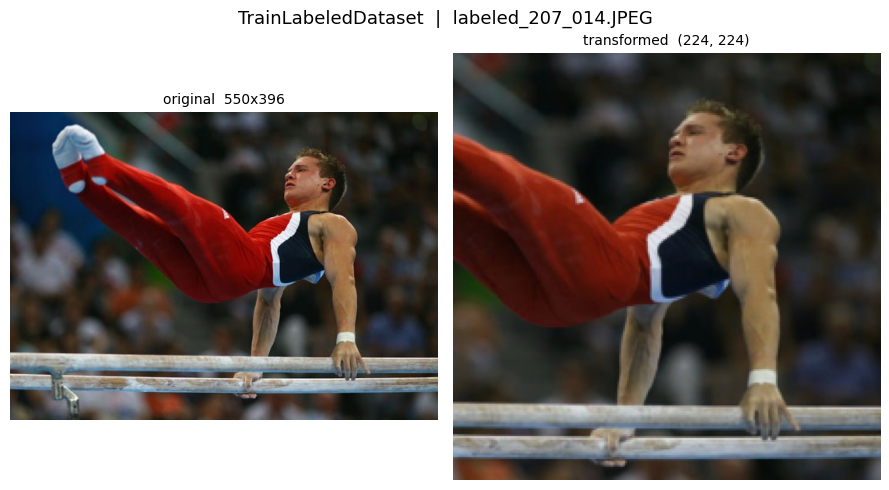

In [3]:
# --- TrainLabeledDataset: image + class_id + filename --------------------------
idx = random.randint(0, 7500)

ds = TrainLabeledDataset(DATA_ROOT, image_transform(train=True))
img_t, label = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # pre-transform

info = CLASS_BY_ID.get(label, {})
show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TrainLabeledDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"class_id      : {label}  (name {info.get('name', '?')}, seg_id {info.get('segmentation_id', '?')})",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

items          : 3000
filename       : seg_083_008.JPEG
segmentation_id: 84  (class ?, name ?)
original size  : (500, 375) (W,H)   transformed: (3, 224, 224) / mask (224, 224)
seg ids in mask: [ 0 84]


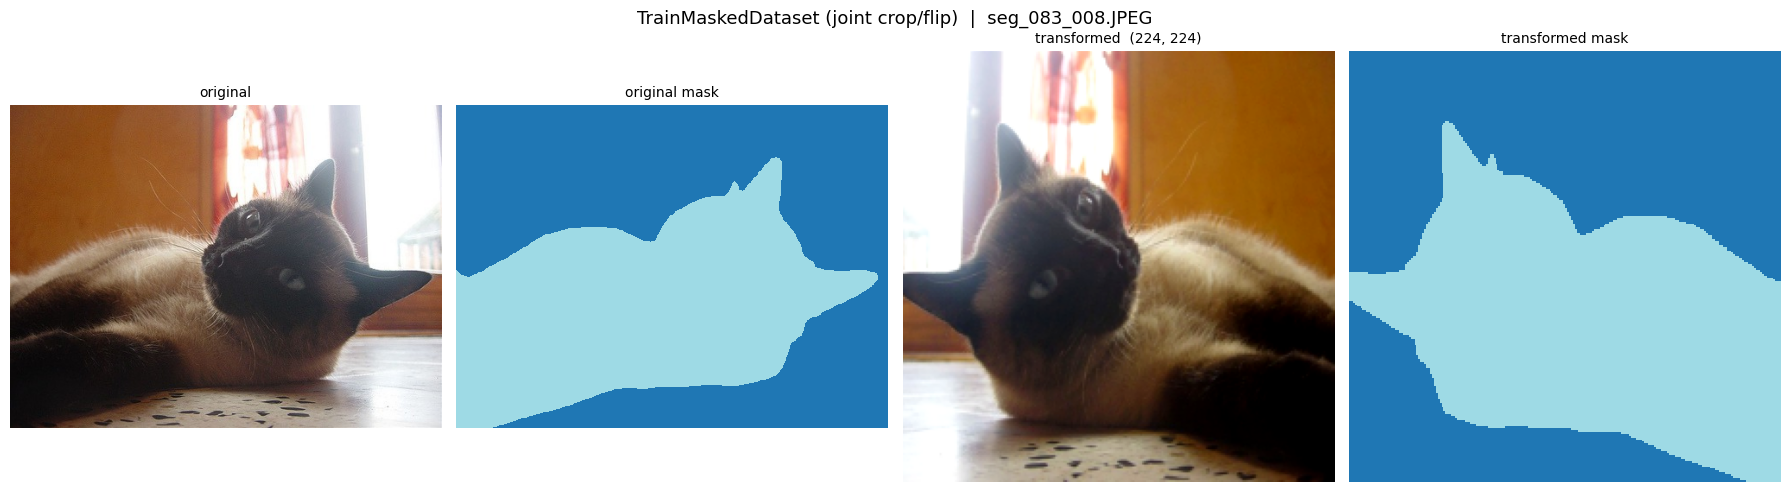

In [4]:
# --- TrainMaskedDataset: image + mask + segmentation_id (JOINT transform) ------
# seg_transform crops/flips the image and mask TOGETHER (nearest on the mask),
# so the foreground stays aligned and seg ids are never blended.
idx = random.randint(0, 3000)

ds = TrainMaskedDataset(DATA_ROOT, seg_transform(train=True))
img_t, mask_t, seg_label = ds[idx]
name = ds.img_names[idx]
item = ds.items[idx]
raw = Image.open(item["image"]).convert("RGB")
raw_mask = rgb_to_seg(np.array(Image.open(DATA_ROOT / item["mask"]).convert("RGB")))

info = CLASS_BY_SEGID.get(seg_label, {})
show_panels(
    [("original", raw),
     ("original mask", raw_mask),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t)),
     ("transformed mask", mask_t.numpy())],
    suptitle=f"TrainMaskedDataset (joint crop/flip)  |  {name}",
    info_lines=[
        f"items          : {len(ds)}",
        f"filename       : {name}",
        f"segmentation_id: {seg_label}  (class {info.get('class_id', '?')}, name {info.get('name', '?')})",
        f"original size  : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} / mask {tuple(mask_t.shape)}",
        f"seg ids in mask: {np.unique(mask_t.numpy())}",
    ],
)

items         : 50000
filename      : unlabeled_030630.JPEG  (no label -- pooled for FCMAE pre-training)
original size : (300, 200) (W,H)   transformed: (3, 224, 224) torch.float32


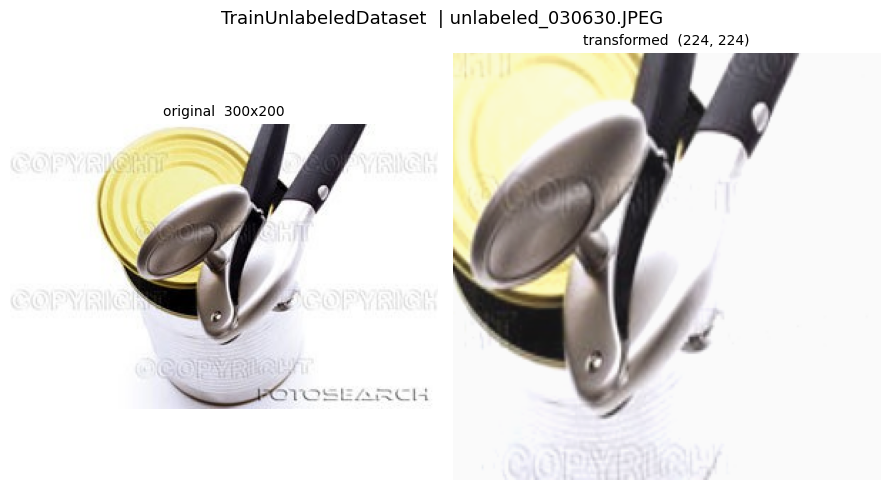

In [5]:
# --- TrainUnlabeledSet: image + filename (no label) ----------------------------
idx = random.randint(0, 50000)

ds = TrainUnlabeledDataset(DATA_ROOT, image_transform(train=True))
img_t = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # items hold full paths here

show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TrainUnlabeledDataset  | {name} ",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}  (no label -- pooled for FCMAE pre-training)",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

items         : 750
filename      : val_00150.JPEG
class_id      : 58  (name ?)
orig size     : tensor([500, 375]) (W,H)   image -> (3, 224, 224)   mask stays (375, 500) (H,W)
seg ids in GT : [ 0 59]


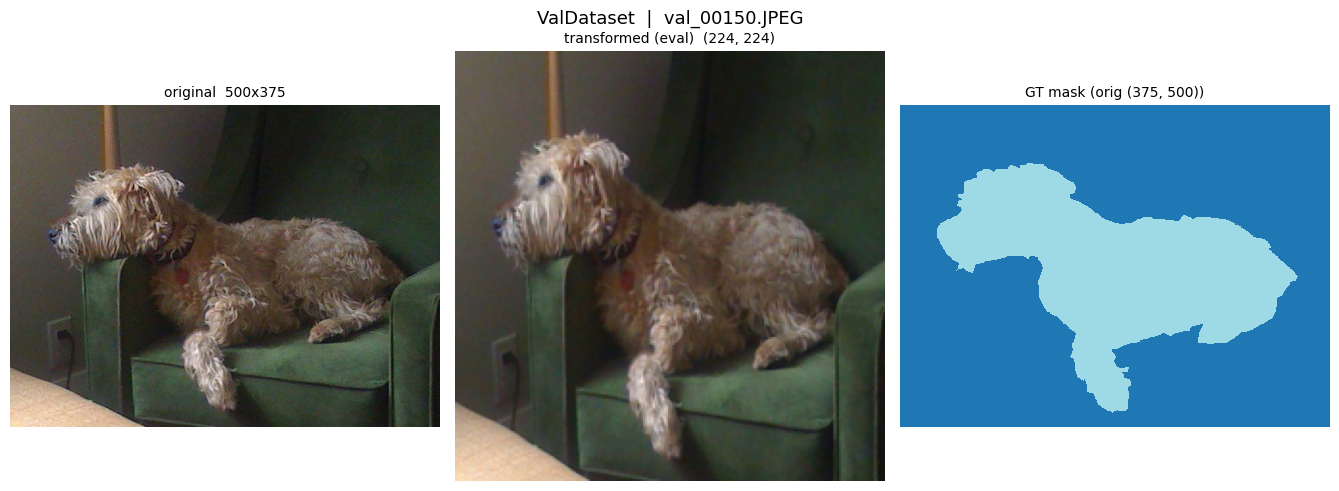

In [6]:
# --- ValDataset: image + GT mask (orig res) + class_id + name + orig size ------
# Eval transform = deterministic resize (no aug). The GT mask is deliberately
# kept at ORIGINAL resolution so val scoring stays exact -- at inference we
# resize the PREDICTION back up (nearest) to compare, never shrink the mask.
idx = random.randint(0, 750)

ds = ValDataset(DATA_ROOT, image_transform(train=False))
img_t, seg_mask, cls_label, orig_size = ds[idx]
name = ds.img_names[idx]
raw = Image.open(DATA_ROOT / "val" / "images" / name).convert("RGB")

info = CLASS_BY_ID.get(cls_label, {})
show_panels(
    [(f"original  {orig_size[0]}x{orig_size[1]}", raw),
     (f"transformed (eval)  {tuple(img_t.shape[1:])}", denormalize(img_t)),
     (f"GT mask (orig {tuple(seg_mask.shape)})", seg_mask.numpy())],
    suptitle=f"ValDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"class_id      : {cls_label}  (name {info.get('name', '?')})",
        f"orig size     : {orig_size} (W,H)   image -> {tuple(img_t.shape)}   mask stays {tuple(seg_mask.shape)} (H,W)",
        f"seg ids in GT : {np.unique(seg_mask.numpy())}",
    ],
)

items         : 3000
filename      : test_00586.JPEG
orig size     : tensor([500, 375]) (W,H) -- predictions must be resized back to this
transformed   : (3, 224, 224) torch.float32


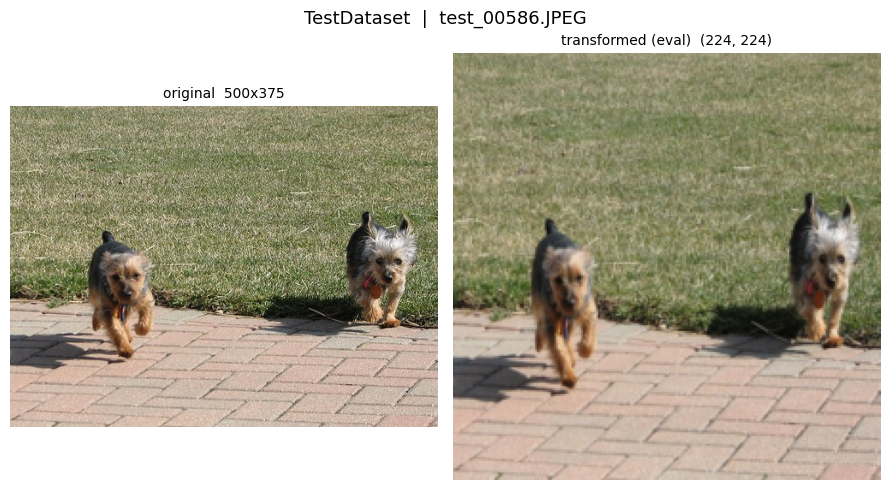

In [7]:
# --- TestDataset: image + filename + orig size (no labels/masks) ---------------
# Eval transform (deterministic resize). orig_size is what predictions must be
# resized back to (nearest) for a valid submission.
idx = random.randint(0, 3000)

ds = TestDataset(DATA_ROOT, image_transform(train=False))
img_t, orig_size = ds[idx]
name = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # items hold full paths

show_panels(
    [(f"original  {orig_size[0]}x{orig_size[1]}", raw),
     (f"transformed (eval)  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"TestDataset  |  {name}",
    info_lines=[
        f"items         : {len(ds)}",
        f"filename      : {name}",
        f"orig size     : {orig_size} (W,H) -- predictions must be resized back to this",
        f"transformed   : {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

pooled items  : 60500  (60500 unlabeled + 7500 labeled + 3000 seg, labels/masks dropped)
filename      : test_00586.JPEG  (no label -- FCMAE pre-training pool)
original size : (500, 343) (W,H)   transformed: (3, 224, 224) torch.float32


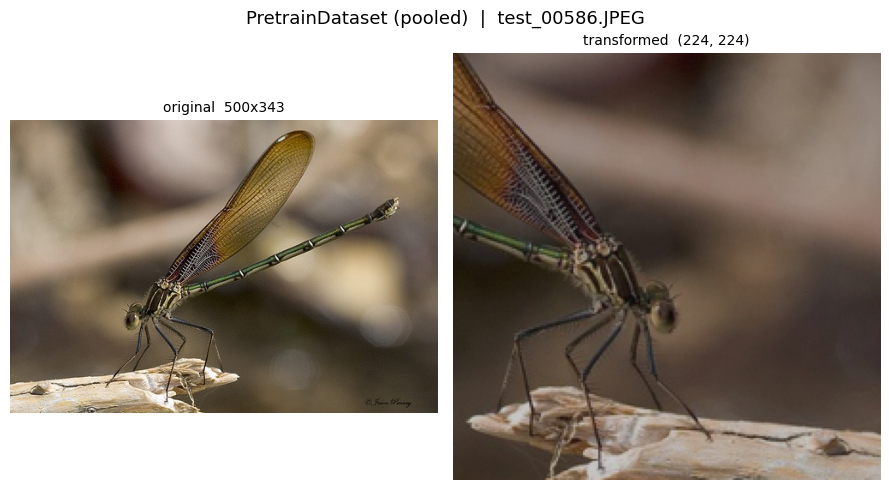

In [8]:
# --- PretrainDataset: pooled image-only set for FCMAE pre-training -------------
# Concatenates train_unlabeled with the items of any datasets you pass (labels
# and masks dropped) into one big image-only pool. Inherits TrainUnlabeledSet,
# so it yields (image, filename).
#
# NOTE: only the unlabeled portion is currently indexable -- pooled labeled/seg
# items keep their data_root-RELATIVE "image" path while __getitem__ opens
# item["image"] directly, so indexing into that portion (idx >= n_unlabeled)
# raises FileNotFoundError. Keep idx in the unlabeled portion; path normalization
# is a known TODO. (Smoke-tested: ds[0] ok, ds[50000] -> FileNotFoundError.)
idx = random.randint(0, 60500)

pooled = [TrainLabeledDataset(DATA_ROOT, image_transform(train=True)),
          TrainMaskedDataset(DATA_ROOT, seg_transform(train=True)),
          TrainUnlabeledDataset(DATA_ROOT, image_transform(train=True))]
ds = PretrainDataset(DATA_ROOT, image_transform(train=True), pooled)
n_unlabeled = len(ds)

img_t = ds[idx]
names = ds.img_names[idx]
raw = Image.open(ds.items[idx]["image"]).convert("RGB")  # unlabeled items hold full paths

show_panels(
    [(f"original  {raw.size[0]}x{raw.size[1]}", raw),
     (f"transformed  {tuple(img_t.shape[1:])}", denormalize(img_t))],
    suptitle=f"PretrainDataset (pooled)  |  {name}",
    info_lines=[
        f"pooled items  : {len(ds)}  ({n_unlabeled} unlabeled + "
        f"{len(pooled[0])} labeled + {len(pooled[1])} seg, labels/masks dropped)",
        f"filename      : {name}  (no label -- FCMAE pre-training pool)",
        f"original size : {raw.size} (W,H)   transformed: {tuple(img_t.shape)} {img_t.dtype}",
    ],
)

### models/
- verify that models are loading and unloading correctly
- verify that models are processing correctly (pass in a dummy image, check for the dimensions that we are expecting)
- set hyperparameters

In [9]:
# TODO

### environment
- check cuda/gpu
- set batch size for best performance - max flops!

#### cuda test

In [10]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


### train engine
- check implementation of training loop
- set 

In [11]:
from src.engines import convnext_cls as cls
import src.models.convnext.convnextv2 as cnv2

model = cnv2.convnextv2_atto()
device = coreutil.get_device()

model.to(device)
ds = TrainLabeledDataset(DATA_ROOT, image_transform(train=True))
data_loader = torch.utils.data.DataLoader(ds, batch_size=20)

cls.predict_one(data_loader, model, device)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

### FCMAE pretraining

The same self-supervised regime as `src.runners.pretrain.run(config)`, laid out
inline so per-epoch loss and reconstruction previews are visible in the notebook.
It pools the three TRAINING splits (50k unlabeled + 7.5k labeled + 3k seg, all
labels/masks dropped) into one image-only set, masks ~60% of each image, and
trains the FCMAE to reconstruct the masked patches (MSE on masked patches only).

The config cell below applies notebook-friendly overrides for a short smoke run
(small `epochs` / `limit` / `num_workers`). For a real run, drop `limit`, raise
`epochs`, and bump `batch_size` to fill the GPU. Logic is unchanged from
`pretrain.run` — it reuses that module's `build_transform` / `build_model` /
`show_modeled_image` plus `train_one_epoch` and the checkpoint helpers.

In [12]:
import dataclasses
import logging
import sys

from src.core.utils import (
    PretrainConfigs, seed_everything, get_device,
    RAND_SEED, DATA_DIR, CHECKPOINT_DIR, SAVE_DIR,
)

# core.utils logs to logs/<date>.log on import; also stream to the notebook so
# train_one_epoch's per-epoch loss shows up in cell output (guard re-runs).
_root = logging.getLogger()
if not any(isinstance(h, logging.StreamHandler) and getattr(h, "stream", None) is sys.stdout
           for h in _root.handlers):
    _root.addHandler(logging.StreamHandler(sys.stdout))
_root.setLevel(logging.INFO)

# Notebook-friendly overrides for a short smoke run. For a full run, drop
# `limit` (use all ~60.5k imgs), raise `epochs`, and bump `batch_size`.
config = PretrainConfigs(
    model_size="atto",
    epochs=500,
    warmup_epochs=40,
    batch_size=16,
    num_workers=0,
    limit=128,
    save_every=1,
    viz_every=1,
)
config

PretrainConfigs(model_size='atto', decoder_depth=1, decoder_embed_dim=512, patch_size=32, mask_ratio=0.6, norm_pix_loss=True, channels=3, size=224, epochs=500, warmup_epochs=40, min_lr=1e-06, blr=0.00015, batch_size=16, weight_decay=0.05, optim_momentum=(0.9, 0.95), num_workers=0, limit=128, save_every=1, update_freq=1, use_amp=True, viz_every=1)

In [13]:
import time
import datetime
from pathlib import Path

import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

from src.engines.fcmae_pretrain import train_one_epoch
from src.runners.pretrain import build_transform, build_model, show_modeled_image
from src.runners.utils import build_param_groups, save_checkpoint, LossScaler

seed_everything(RAND_SEED)
device = get_device()
cudnn.benchmark = True
print(f"FCMAE pretraining on {device} | model_size={config.model_size}")

# --- data: pool the three training splits into one image-only set -------------
transform = build_transform(config)
labeled = TrainLabeledDataset(DATA_DIR, transform)
masked = TrainMaskedDataset(DATA_DIR, transform)
dataset = PretrainDataset(DATA_DIR, transform, [labeled, masked])
if config.limit > 0:
    dataset.items = dataset.items[: config.limit]
print(f"Pre-training pool: {len(dataset)} images")

loader = DataLoader(
    dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=(device.type == "cuda"),
    drop_last=True,
)

# --- model / optimizer / amp --------------------------------------------------
model = build_model(config).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model params: {n_params / 1e6:.2f}M")

eff_batch_size = config.batch_size * config.update_freq
lr = config.blr * eff_batch_size / 256
print(f"base lr={config.blr:.2e} | eff batch size={eff_batch_size} | actual lr={lr:.2e}")

param_groups = build_param_groups(model, config.weight_decay)
optimizer = torch.optim.AdamW(param_groups, lr=lr, betas=config.optim_momentum)
loss_scaler = LossScaler(config.use_amp, device.type)

# cache one batch for reconstruction previews (only if enabled)
viz_batch = None
if config.viz_every > 0:
    viz_batch = next(iter(loader)).to(device, non_blocking=True)

# --- training loop ------------------------------------------------------------
ckpt_dir = Path(CHECKPOINT_DIR)
start_time = time.time()
for epoch in range(config.epochs):
    train_one_epoch(
        model, loader, optimizer, device, epoch,
        loss_scaler, lr, config, config.update_freq,
    )

    is_last = epoch + 1 == config.epochs
    if (epoch + 1) % config.save_every == 0 or is_last:
        ckpt_path = ckpt_dir / f"checkpoint-{epoch}.pth"
        save_checkpoint(
            model, ckpt_path,
            optimizer=optimizer, loss_scaler=loss_scaler,
            epoch=epoch, config=config,
        )
        print(f"Saved checkpoint to {ckpt_path}")

    if viz_batch is not None and ((epoch + 1) % config.viz_every == 0 or is_last):
        show_modeled_image(model, viz_batch, config, epoch + 1, SAVE_DIR)

total_time = datetime.timedelta(seconds=int(time.time() - start_time))
print(f"FCMAE pre-training done in {total_time}")

FCMAE pretraining on cuda | model_size=atto
Pre-training pool: 128 images
Model params: 7.26M
base lr=1.50e-04 | eff batch size=16 | actual lr=9.37e-06


W0606 07:11:57.179000 326 torch/fx/_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


tensor([[0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
         1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0.,
         0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.],
        [1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1.,
         0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
         1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0.],
        [0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 0.,
         1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1.,
         0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1.],
        [1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1.,
         0., 0., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 0.,
         1., 0., 1., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 0., 1.

/usr/local/lib/python3.12/dist-packages/spconv/pytorch/core.py:127: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  ret[slices] = updates.view(*output_shape)


Shape at start of block: torch.Size([16, 512, 7, 7])
Shape at depthwise conv: torch.Size([16, 512, 7, 7])
They permute the shape here: torch.Size([16, 7, 7, 512])
Shape after normalization: torch.Size([16, 7, 7, 512])
Shape after 1x1 conv: torch.Size([16, 7, 7, 2048])
Shape after GELU: torch.Size([16, 7, 7, 2048])
Shape after GRN: torch.Size([16, 7, 7, 2048])
Shape after another pointwise conv: torch.Size([16, 7, 7, 512])
Another shape change?: torch.Size([16, 512, 7, 7])


KeyboardInterrupt: 

In [ ]:
# Display the latest reconstruction preview written by show_modeled_image
# (rows of: original | masked | reconstruction). Requires config.viz_every > 0.
previews = sorted(Path(SAVE_DIR).glob("recon_epoch*.png"),
                  key=lambda p: int(p.stem.removeprefix("recon_epoch")))
if previews:
    latest = previews[-1]
    plt.figure(figsize=(9, 9))
    plt.imshow(Image.open(latest))
    plt.axis("off")
    plt.title(latest.name)
    plt.show()
else:
    print(f"No reconstruction previews in {SAVE_DIR} (set config.viz_every > 0 and re-run).")

In [20]:
from src.models.convnext.fcmae import FCMAE

f = FCMAE()

In [33]:
t = torch.ones([1, 64, 64])
t

tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]]])

In [34]:
f.gen_random_mask(t, 0.5)

tensor([[1., 1., 0., 0.]])


tensor([[1., 1., 0., 0.]])